# Task 3b: Held-Out TDK Evaluation

This notebook evaluates the single checkpoint selected using **non-TDK validation WER** in Task 3a. It does not tune parameters on TDK. The baseline `generated_text` is preserved, and `generated_text_ft` is added. Python helpers implement resumable inference; this notebook records the experiment and comparison.

Default mode replays the recorded full-corpus result on CPU. Set RUN_TDK_INFERENCE=1, YCSEP_MODEL and TDK_CACHE explicitly to run new inference. The model was selected using non-TDK validation only.

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'asr-train':
    ROOT = ROOT.parent
sys.path[:0] = [str(ROOT / 'asr-train'), str(ROOT / 'asr')]
BASE = Path(os.environ.get('TDK_BASE', ROOT / 'asr/TDK_subset.csv'))
MODEL = Path(os.environ.get('YCSEP_MODEL', ROOT / 'asr-train/models/parakeet-tdt-0.6b-v3-ycsep.nemo'))
OUTPUT = Path(os.environ.get('TDK_EVALUATION', ROOT / 'test_docs/test/runtime/final-tdk-evaluation'))
CACHE = os.environ.get('TDK_CACHE') or None

rerun = os.environ.get('RUN_TDK_INFERENCE') == '1'
OUTPUT.mkdir(parents=True, exist_ok=True)

## Audio and Reproducibility
Prefer the verified MP3 caches from Task 2c so the two models see identical audio. If unavailable, the helper extracts the original YCSEP WAV timestamp range and encodes MP3 using the same fallback as Task 2c. This is not byte-identical to the CSV's original MP3; report which path was used. Both paths use librosa mono 16 kHz loading followed by PCM WAV, matching the API preprocessing. The checkpoint and baseline CSV hashes bind the resume journal.

Before the final run, confirm that the baseline has **all 218,011 TDK rows** and zero API errors. Empty successful transcriptions are valid model outputs, not missing rows.

In [2]:
import csv
with BASE.open(encoding='utf-8-sig', newline='') as handle:
    baseline_rows = list(csv.DictReader(handle))
assert len(baseline_rows) == 218011, 'Final TDK baseline is incomplete'
assert all(r['channel'] == 'The_Daily_Ketchup_Podcast' and not r['asr_error'] for r in baseline_rows)
if rerun:
    assert MODEL.is_file(), 'Selected Task 3a model is required'
print({'baseline_rows': len(baseline_rows), 'checkpoint': MODEL.name})


{'baseline_rows': 218011, 'checkpoint': 'parakeet-tdt-0.6b-v3-ycsep.nemo'}


In [3]:
if rerun:
    from evaluate_tdk import evaluate
    result = evaluate(BASE, MODEL, OUTPUT, batch_size=8, workers=8, cache=CACHE)
    raw = OUTPUT / 'TDK_subset_ft.csv'
else:
    assert all('generated_text_ft' in r and not r['asr_error_ft'] for r in baseline_rows)
    result = json.loads((ROOT / 'asr-train/results/E3-TDK/evaluation-provenance.json').read_text())
    raw = BASE
    print('Replaying recorded full-corpus predictions; no GPU inference.')
result

Replaying recorded full-corpus predictions; no GPU inference.


{'rows': 218011,
 'failed': 0,
 'model_sha256': 'c7c194c87490455b673cc7ad713d53a760231e236ad5dfb365eab585c8a81877',
 'shards': [{'index': 0,
   'rows': 27252,
   'csv_sha256': 'a2c6e347ce47a7c1e740918ccafeff803d9ab10910e01299a0d7ede448156003'},
  {'index': 1,
   'rows': 27252,
   'csv_sha256': '8c45de3d4d85cb1429973d1f6b8e37a3c60e7ef0539d3f5282636cb1e45d29b1'},
  {'index': 2,
   'rows': 27252,
   'csv_sha256': 'f4667be047b060ca3185cc8edbca20b1cf11bb0218a055c32f72f68f3d82c4c8'},
  {'index': 3,
   'rows': 27251,
   'csv_sha256': '24bce517faccf594edb9483a138e58416f23d74d62cb5530a178701d50a94fe4'},
  {'index': 4,
   'rows': 27251,
   'csv_sha256': '4c0074c2f25d331f5dd7bf702661cd7596a337945749185f5fb5dc7f1ccd36c3'},
  {'index': 5,
   'rows': 27251,
   'csv_sha256': '5f40c3317b8bf3691fa3977b458d35b2f5921ba8755fdcdceae10d8a0618471e'},
  {'index': 6,
   'rows': 27251,
   'csv_sha256': 'cac6d0c12ac5308e71b7de20f8f3ed610c7963a1f556cb4814c99b80107933f5'},
  {'index': 7,
   'rows': 27251,
   'csv_

## Paired Metrics
WER is the primary metric, calculated as pooled substitutions + deletions + insertions divided by total reference words, not the mean of row WER. CER is secondary. The same Unicode NFKC/case-fold/word normalization is applied to both systems; CER excludes spaces. Empty-reference rows retain insertion counts in the pooled numerator. Failed inference must be resolved before declaring final performance.

In [4]:
from score_transcriptions import score
base_metrics = score(raw, OUTPUT / 'TDK_base_scored.csv')
ft_metrics = score(OUTPUT / 'TDK_base_scored.csv', OUTPUT / 'TDK_subset.csv',
                   prediction='generated_text_ft', suffix='ft', error_column='asr_error_ft')
assert base_metrics['coverage'] == ft_metrics['coverage'] == 1
comparison = {'base_wer': base_metrics['corpus_wer'], 'ft_wer': ft_metrics['corpus_wer'],
              'base_cer': base_metrics['corpus_cer'], 'ft_cer': ft_metrics['corpus_cer']}
comparison['absolute_wer_change'] = comparison['ft_wer'] - comparison['base_wer']
comparison['relative_wer_reduction'] = (1-comparison['ft_wer']/comparison['base_wer']) if comparison['base_wer'] else None
(OUTPUT / 'comparison.json').write_text(json.dumps(comparison, indent=2), encoding='utf-8')
from compare_models import compare
paired = compare(OUTPUT / 'TDK_subset.csv', OUTPUT)
assert abs(paired['base_wer'] - comparison['base_wer']) < 1e-12
assert abs(paired['ft_wer'] - comparison['ft_wer']) < 1e-12
paired


{
  "rows": 218011,
  "scored": 218011,
  "failed": 0,
  "word_edits": 607513,
  "reference_words": 2487035,
  "character_edits": 1831500,
  "reference_characters": 10103081,
  "empty_references": 0,
  "corpus_wer": 0.2442719945638079,
  "corpus_cer": 0.1812813338822088,
  "coverage": 1.0,
  "normalization": "unicode_nfkc_casefold_words_apostrophes_v1; CER excludes spaces",
  "prediction_column": "generated_text",
  "source_sha256": "6debc6f58dd74665c1d68d04e6c9fa81ffb37ca6f9326187d9a3093046de3713"
}


{
  "rows": 218011,
  "scored": 218011,
  "failed": 0,
  "word_edits": 474249,
  "reference_words": 2487035,
  "character_edits": 1435843,
  "reference_characters": 10103081,
  "empty_references": 0,
  "corpus_wer": 0.19068851061605485,
  "corpus_cer": 0.1421193198391659,
  "coverage": 1.0,
  "normalization": "unicode_nfkc_casefold_words_apostrophes_v1; CER excludes spaces",
  "prediction_column": "generated_text_ft",
  "source_sha256": "6debc6f58dd74665c1d68d04e6c9fa81ffb37ca6f9326187d9a3093046de3713"
}


{'scope': 'full_tdk',
 'rows': 218011,
 'videos': 367,
 'failed_rows': 0,
 'base_wer': 0.2442719945638079,
 'ft_wer': 0.19068851061605485,
 'base_cer': 0.1812813338822088,
 'ft_cer': 0.1421193198391659,
 'delta_wer': -0.053583483947753044,
 'relative_wer_reduction': 0.21935991493186155,
 'delta_wer_95pct_video_bootstrap': [-0.05496140591739777,
  -0.05223373290102009],
 'valid_bootstrap_draws': 2000,
 'bootstrap_samples': 2000,
 'seed': 2026,
 'normalization': 'unicode_nfkc_casefold_words_apostrophes_v1; CER excludes spaces',
 'bootstrap_assumption': 'Videos treated as independent clusters; recurring speakers can violate this assumption'}

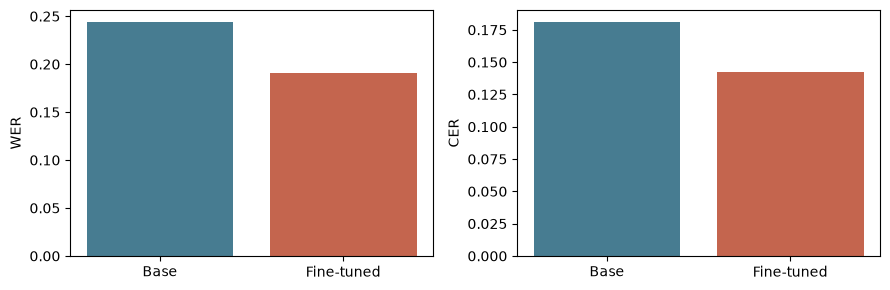

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, metric in zip(axes, ('wer', 'cer')):
    ax.bar(['Base', 'Fine-tuned'], [comparison['base_'+metric], comparison['ft_'+metric]], color=['#477c91', '#c4654e'])
    ax.set_ylabel(metric.upper())
    ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()


In [6]:
from analyze_errors import analyze
analyze(OUTPUT / 'TDK_subset.csv', OUTPUT)


{'interpretation': 'Post-test descriptive slices, not tuning criteria. Short segments and reference alignment may confound results.',
 'row_outcomes': {'improved': 80758, 'unchanged': 108974, 'regressed': 28279},
 'video_outcomes': {'improved': 367},
 'slices': {'all': {'rows': 218011,
   'words': 2487035,
   'base_edits': 607513,
   'ft_edits': 474249,
   'base_wer': 0.2442719945638079,
   'ft_wer': 0.19068851061605485},
  'duration:2-5s': {'rows': 62338,
   'words': 790503,
   'base_edits': 192069,
   'ft_edits': 151806,
   'base_wer': 0.24297061491227737,
   'ft_wer': 0.19203722187012573},
  'duration:5-10s': {'rows': 29134,
   'words': 780489,
   'base_edits': 132329,
   'ft_edits': 106366,
   'base_wer': 0.16954627163227157,
   'ft_wer': 0.13628122881936838},
  'duration:<2s': {'rows': 117758,
   'words': 437040,
   'base_edits': 217684,
   'ft_edits': 164013,
   'base_wer': 0.49808713161266704,
   'ft_wer': 0.37528143876990666},
  'duration:>=10s': {'rows': 8781,
   'words': 4790

## Observed Full-TDK Results: E3
All 218,011 rows across 367 videos scored successfully. WER improves from 24.4272% to 19.0689%: 5.3583 percentage points, or 21.9360% relative. CER improves from 18.1281% to 14.2119%. Word edits fall from 607,513 to 474,249 over 2,487,035 reference words.

The 2,000-draw video-bootstrap 95% interval for FT-minus-base WER is [-5.4961, -5.2234] percentage points. Related videos and recurring speakers may violate cluster independence. All 367 videos improve in aggregate, but 28,279 rows regress; this does not guarantee correctness for each clip.

E3 was chosen by non-TDK validation, not TDK results. E1 remains a historical release (21.3120% TDK WER). E4 is excluded due to inconsistent resumed validation/checkpoint selection. No further tuning on TDK is justified.


## E3 artifact identity and complete coverage
The default public manifest, model, CSV and this notebook all identify E3. All eight shards passed exact baseline-order, coverage, model-checksum and cached-audio checks. The historical E1 release is retained separately. E4 is excluded. These TDK results are reporting evidence, not a training-selection signal.


In [7]:
from pathlib import Path
import json
r=Path.cwd()
if not (r/'asr-train').exists(): r=r.parent
print(json.dumps(json.loads((r/'asr-train/results/E3-TDK/comparison.json').read_text()),indent=2))

{
  "scope": "full_tdk",
  "rows": 218011,
  "videos": 367,
  "failed_rows": 0,
  "base_wer": 0.2442719945638079,
  "ft_wer": 0.19068851061605485,
  "base_cer": 0.1812813338822088,
  "ft_cer": 0.1421193198391659,
  "delta_wer": -0.053583483947753044,
  "relative_wer_reduction": 0.21935991493186155,
  "delta_wer_95pct_video_bootstrap": [
    -0.05496140591739777,
    -0.05223373290102009
  ],
  "valid_bootstrap_draws": 2000,
  "bootstrap_samples": 2000,
  "seed": 2026,
  "normalization": "unicode_nfkc_casefold_words_apostrophes_v1; CER excludes spaces",
  "bootstrap_assumption": "Videos treated as independent clusters; recurring speakers can violate this assumption"
}
